<a href="https://colab.research.google.com/github/lucasm9302/EDA_Tesis/blob/main/EDA_Casi_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bloque 1: Importación de librerías y carga de datos

In [6]:
# 1. Agreguemos los paquetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OneHotEncoder


import os
# Crear carpeta para guardar imágenes automáticamente
os.makedirs('/content/imagenes_eda', exist_ok=True)

# Ignorar advertencias de futuras versiones
warnings.filterwarnings('ignore')

# 2. Carguemos los datos
df = pd.read_csv('/content/acData.csv')
print("Datos originales cargados. Dimensiones:", df.shape)

Datos originales cargados. Dimensiones: (2466, 12)


### Bloque 2: Ingeniería de Características (Feature Engineering)

Antes de explorar, construimos el historial de los clientes y las ventanas temporales para evitar la fuga de datos.

In [7]:
# Convertimos fechas a formato datetime
date_cols = ['InvoiceDate', 'DueDate', 'PaperlessDate', 'SettledDate']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Ordenamos cronológicamente (para variables históricas)
df = df.sort_values(by=['customerID', 'InvoiceDate']).reset_index(drop=True)

# --- CREACIÓN DE VARIABLES ---
# Variable Objetivo
df['Target_EsAtrasado'] = (df['DaysLate'] > 0).astype(int)

# Transformaciones básicas
df['PaperlessBill_Bin'] = (df['PaperlessBill'] == 'Electronic').astype(int)
df['Disputed_Bin'] = (df['Disputed'] == 'Yes').astype(int)
df['countryCode'] = df['countryCode'].astype(str) # Se trata como categoría

# Variables temporales
df['Plazo_Pago'] = (df['DueDate'] - df['InvoiceDate']).dt.days
df['Dias_Desde_Paperless'] = (df['InvoiceDate'] - df['PaperlessDate']).dt.days
df['Dias_Desde_Paperless'] = df['Dias_Desde_Paperless'].clip(lower=0)
df['Mes_Emision'] = df['InvoiceDate'].dt.month
df['Dia_Semana_Vencimiento'] = df['DueDate'].dt.dayofweek

# Historial del cliente (Window Functions con .shift(1))
df['Tasa_Atraso_Historico'] = df.groupby('customerID')['Target_EsAtrasado'].transform(lambda x: x.shift(1).expanding().mean()).fillna(0)
df['Promedio_Dias_Atraso_Historico'] = df.groupby('customerID')['DaysLate'].transform(lambda x: x.shift(1).expanding().mean()).fillna(0)
df['Facturas_Disputadas_Pasadas'] = df.groupby('customerID')['Disputed_Bin'].transform(lambda x: x.shift(1).expanding().sum()).fillna(0)
df['Facturas_Totales_Pasadas'] = df.groupby('customerID').cumcount()

# PRIMERA LIMPIEZA
# Eliminamos columnas que causan fuga de datos o son identificadores
columnas_a_eliminar = [
    'customerID', 'invoiceNumber', 'SettledDate', 'DaysToSettle', 'DaysLate',
    'PaperlessDate', 'PaperlessBill', 'Disputed', 'InvoiceDate', 'DueDate'
]
df_eda = df.drop(columns=columnas_a_eliminar)

### Bloque 3: Inspección inicial del Dataset

Verificamos la estructura y la calidad de los datos.

In [8]:
# 3. y 4. Mostrar las primeras y últimas filas
display(df_eda.head())
display(df_eda.tail())

# 5. Información del dataset
df_eda.info()

# 6. Veamos los datos faltantes o NaNs
missing_values = df_eda.isna().sum()
total_rows = df_eda.shape[0]
missing_info_df = pd.DataFrame({
    'Datos faltantes': missing_values,
    'Porcentaje (%)': round((missing_values / total_rows) * 100, 2)
})
display(missing_info_df)

,countryCode,InvoiceAmount,Target_EsAtrasado,PaperlessBill_Bin,Disputed_Bin,Plazo_Pago,Dias_Desde_Paperless,Mes_Emision,Dia_Semana_Vencimiento,Tasa_Atraso_Historico,Promedio_Dias_Atraso_Historico,Facturas_Disputadas_Pasadas,Facturas_Totales_Pasadas
0,391,62.68,0,0,1,30,0,3,5,0.0,0.0,0.0,0
1,391,77.19,0,0,0,30,0,5,3,0.0,0.0,1.0,1
2,391,51.65,0,0,0,30,0,5,2,0.0,0.0,1.0,2
3,391,64.47,0,0,1,30,0,6,0,0.0,0.0,1.0,3
4,391,84.57,0,0,0,30,0,9,4,0.0,0.0,2.0,4


,countryCode,InvoiceAmount,Target_EsAtrasado,PaperlessBill_Bin,Disputed_Bin,Plazo_Pago,Dias_Desde_Paperless,Mes_Emision,Dia_Semana_Vencimiento,Tasa_Atraso_Historico,Promedio_Dias_Atraso_Historico,Facturas_Disputadas_Pasadas,Facturas_Totales_Pasadas
2461,770,58.83,1,1,0,30,417,5,5,0.823529,4.764706,2.0,17
2462,770,66.38,1,1,0,30,439,5,6,0.833333,4.666667,2.0,18
2463,770,53.29,0,1,0,30,524,8,0,0.842105,4.842105,2.0,19
2464,770,69.29,1,1,0,30,534,9,3,0.800000,4.600000,2.0,20
2465,770,54.16,0,1,0,30,621,11,6,0.809524,4.428571,2.0,21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   countryCode                     2466 non-null   object 
 1   InvoiceAmount                   2466 non-null   float64
 2   Target_EsAtrasado               2466 non-null   int64  
 3   PaperlessBill_Bin               2466 non-null   int64  
 4   Disputed_Bin                    2466 non-null   int64  
 5   Plazo_Pago                      2466 non-null   int64  
 6   Dias_Desde_Paperless            2466 non-null   int64  
 7   Mes_Emision                     2466 non-null   int32  
 8   Dia_Semana_Vencimiento          2466 non-null   int32  
 9   Tasa_Atraso_Historico           2466 non-null   float64
 10  Promedio_Dias_Atraso_Historico  2466 non-null   float64
 11  Facturas_Disputadas_Pasadas     2466 non-null   float64
 12  Facturas_Totales_Pasadas        24

,Datos faltantes,Porcentaje (%)
countryCode,0,0.0
InvoiceAmount,0,0.0
Target_EsAtrasado,0,0.0
PaperlessBill_Bin,0,0.0
Disputed_Bin,0,0.0
Plazo_Pago,0,0.0
Dias_Desde_Paperless,0,0.0
Mes_Emision,0,0.0
Dia_Semana_Vencimiento,0,0.0
Tasa_Atraso_Historico,0,0.0


### Bloque 4: Resumen Estadístico

Calculamos las métricas descriptivas para la variable respuesta, variables numéricas y categóricas

In [9]:
pd.set_option('display.precision', 2)

# 7. Resumen estadístico de la variable respuesta
print("--- Variable Respuesta ---")
display(df_eda['Target_EsAtrasado'].describe())

# 8. Resumen estadístico de las variables numéricas independientes
print("\n--- Variables Numéricas Predictoras ---")
display(df_eda.drop(columns=['Target_EsAtrasado', 'countryCode']).describe().T)

# 9. Resumen estadístico de la variable categórica (countryCode)
conteo = df_eda['countryCode'].value_counts()
proporciones = df_eda['countryCode'].value_counts(normalize=True)
resultado_cat = pd.DataFrame({'Conteo': conteo, 'Proporción': proporciones})
print("\n--- Variable Categórica ---")
display(resultado_cat)

--- Variable Respuesta ---


,Target_EsAtrasado
count,2466.00
mean,0.36
std,0.48
min,0.00
25%,0.00
50%,0.00
75%,1.00
max,1.00



--- Variables Numéricas Predictoras ---


,count,mean,std,min,25%,50%,75%,max
InvoiceAmount,2466.0,59.90,20.44,5.26,46.4,60.56,73.77,128.28
PaperlessBill_Bin,2466.0,0.49,0.50,0.00,0.0,0.00,1.00,1.00
Disputed_Bin,2466.0,0.23,0.42,0.00,0.0,0.00,0.00,1.00
Plazo_Pago,2466.0,30.00,0.00,30.00,30.0,30.00,30.00,30.00
Dias_Desde_Paperless,2466.0,107.84,153.65,0.00,0.0,0.00,193.00,676.00
Mes_Emision,2466.0,6.35,3.32,1.00,3.0,6.00,9.00,12.00
Dia_Semana_Vencimiento,2466.0,2.97,2.01,0.00,1.0,3.00,5.00,6.00
Tasa_Atraso_Historico,2466.0,0.38,0.37,0.00,0.0,0.25,0.71,1.00
Promedio_Dias_Atraso_Historico,2466.0,3.80,4.85,0.00,0.0,1.59,6.42,31.00
Facturas_Disputadas_Pasadas,2466.0,2.79,4.26,0.00,0.0,1.00,4.00,26.00



--- Variable Categórica ---


,Conteo,Proporción
countryCode,,
391,616,0.25
406,561,0.23
770,506,0.21
897,396,0.16
818,387,0.16


### Bloque 5: Visualizaciones Univariadas

Generamos histogramas y diagramas de caja iterativos, extrayendo asimetría y curtosis.

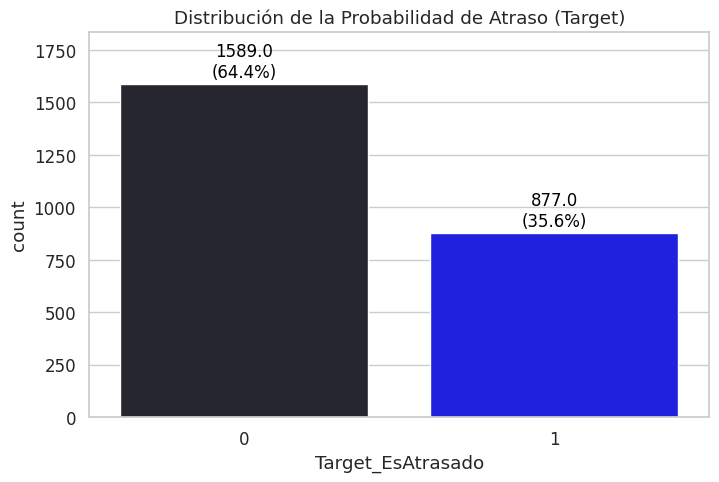

Columna: InvoiceAmount
Asimetría (Skew): -0.12
Curtosis: -0.1


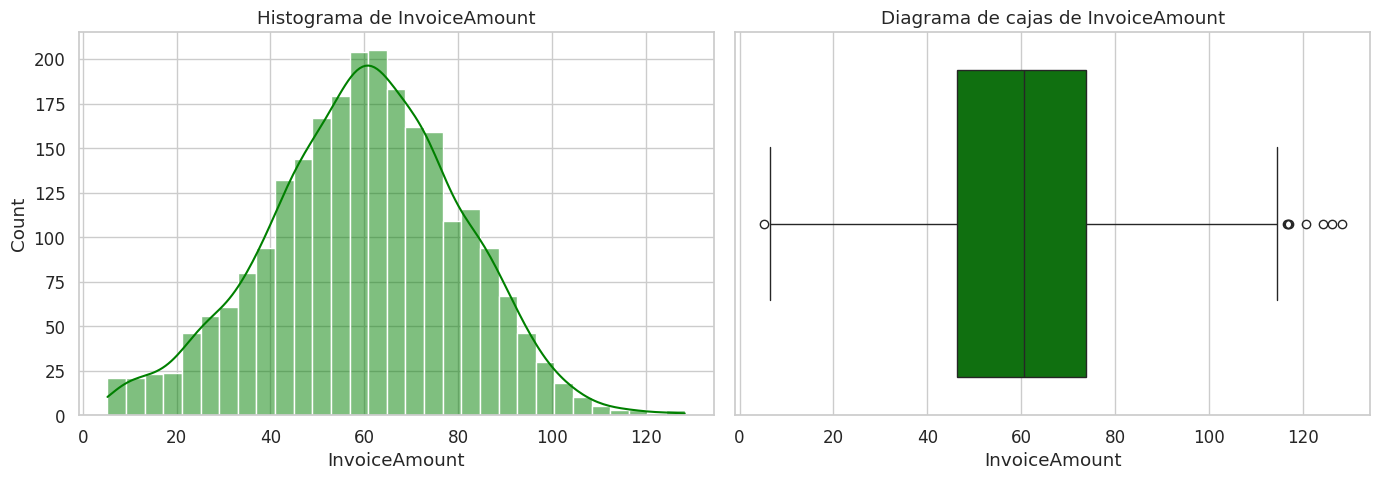

Columna: PaperlessBill_Bin
Asimetría (Skew): 0.05
Curtosis: -2.0


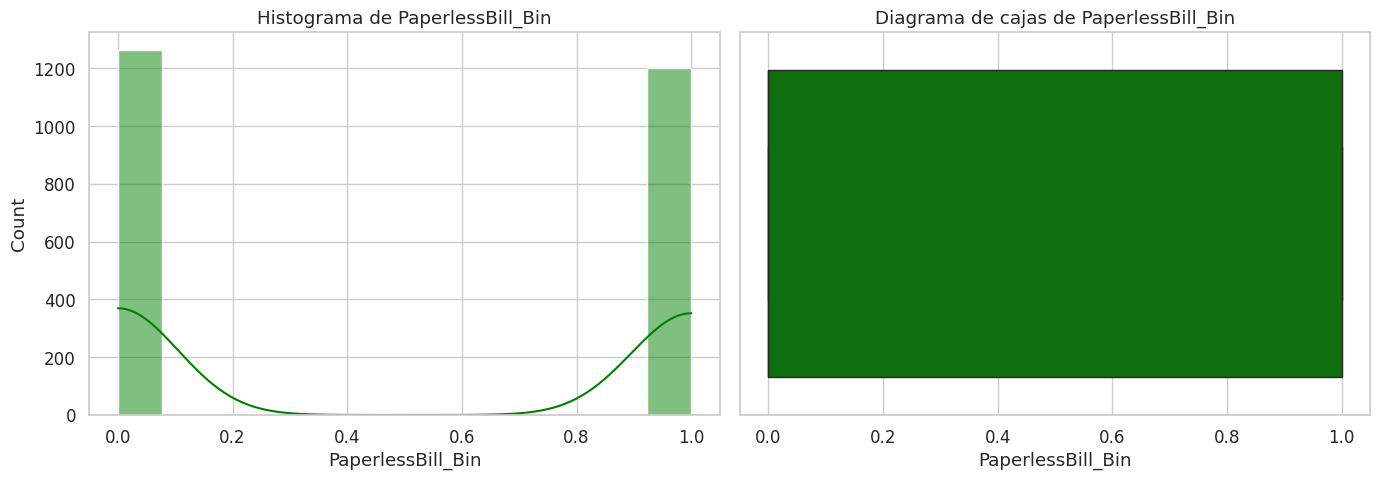

Columna: Disputed_Bin
Asimetría (Skew): 1.3
Curtosis: -0.31


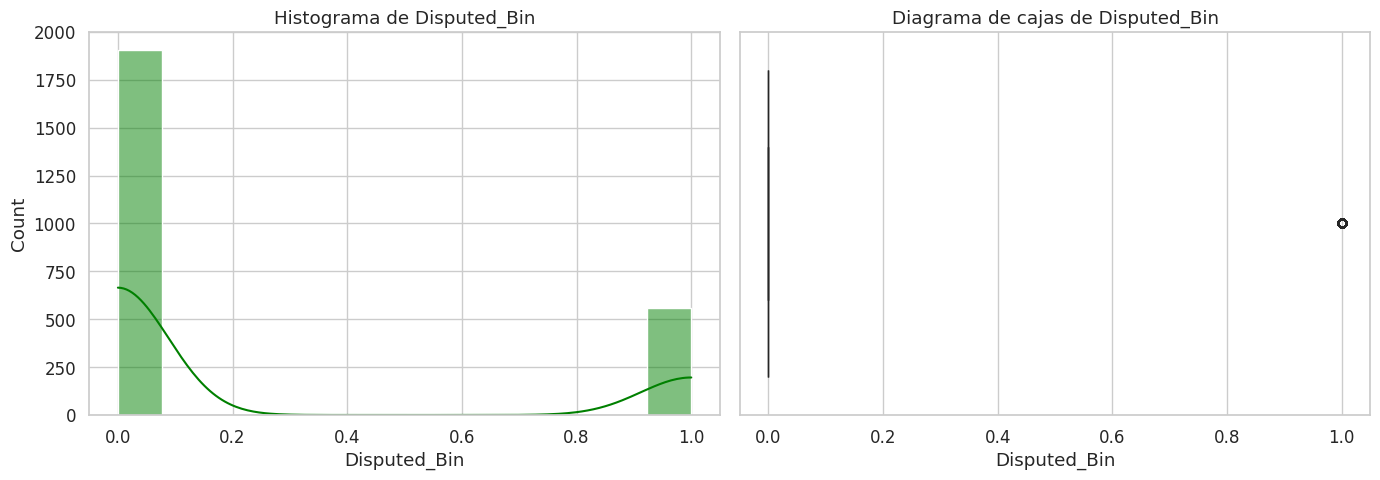

Columna: Plazo_Pago
Asimetría (Skew): 0.0
Curtosis: 0.0


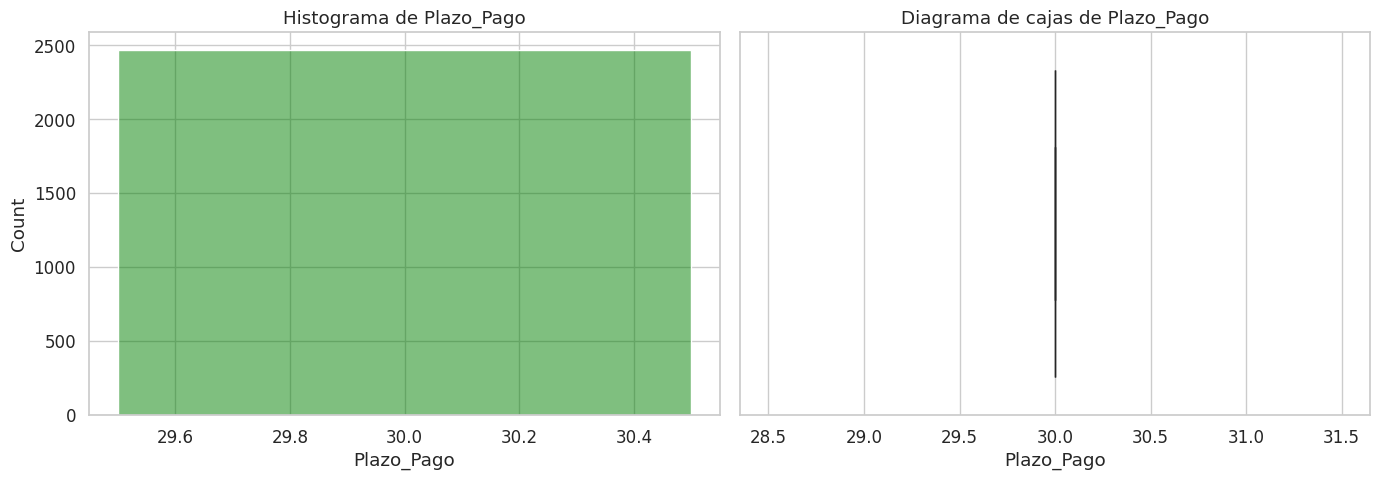

Columna: Dias_Desde_Paperless
Asimetría (Skew): 1.36
Curtosis: 0.83


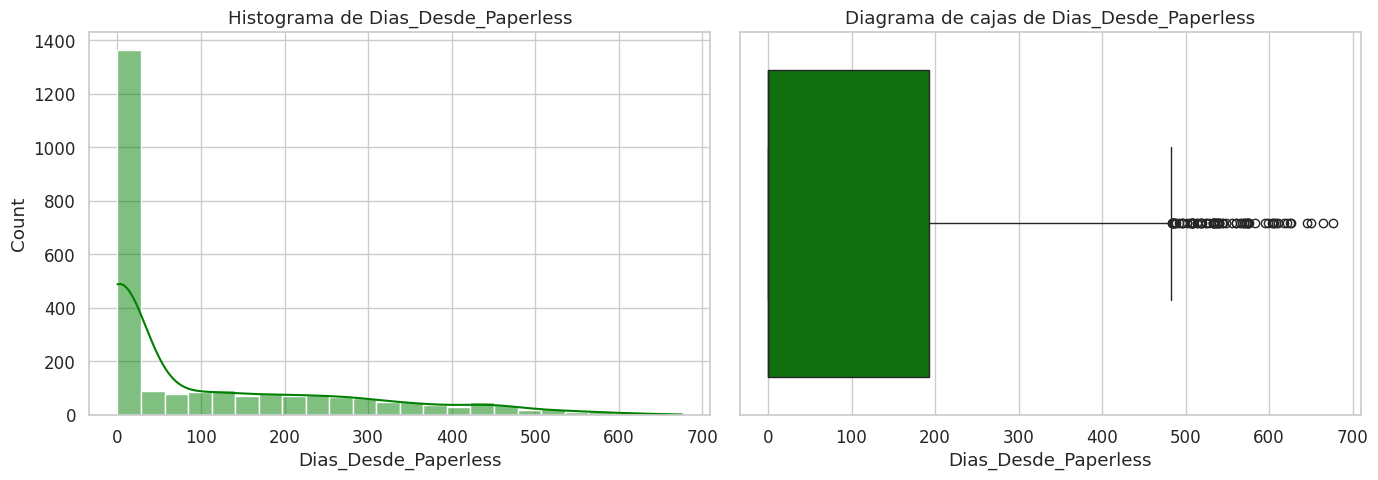

Columna: Mes_Emision
Asimetría (Skew): 0.01
Curtosis: -1.18


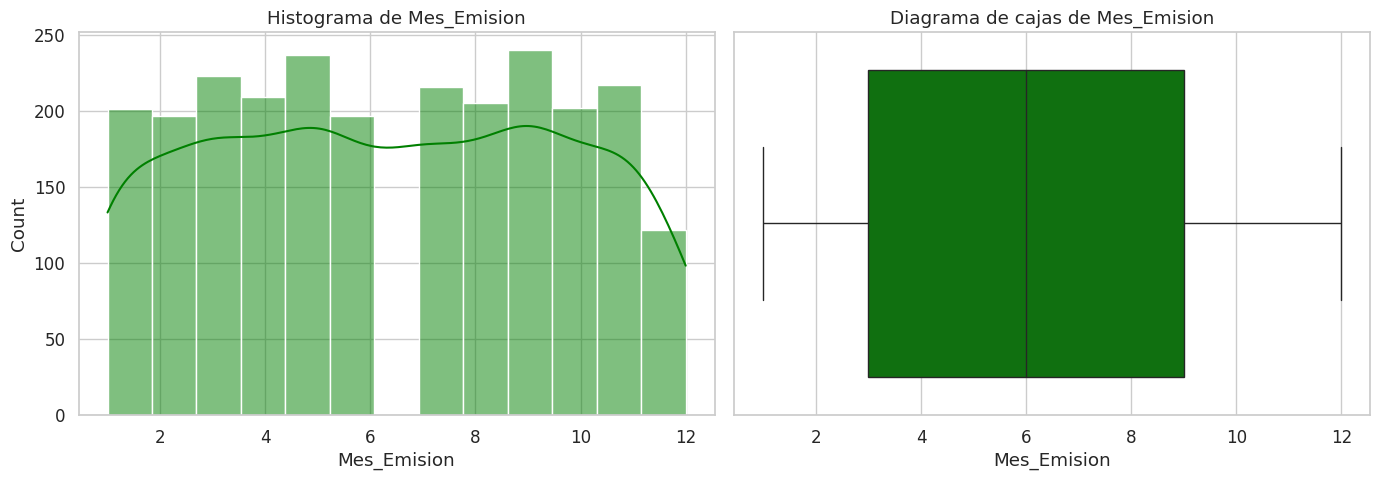

Columna: Dia_Semana_Vencimiento
Asimetría (Skew): 0.01
Curtosis: -1.26


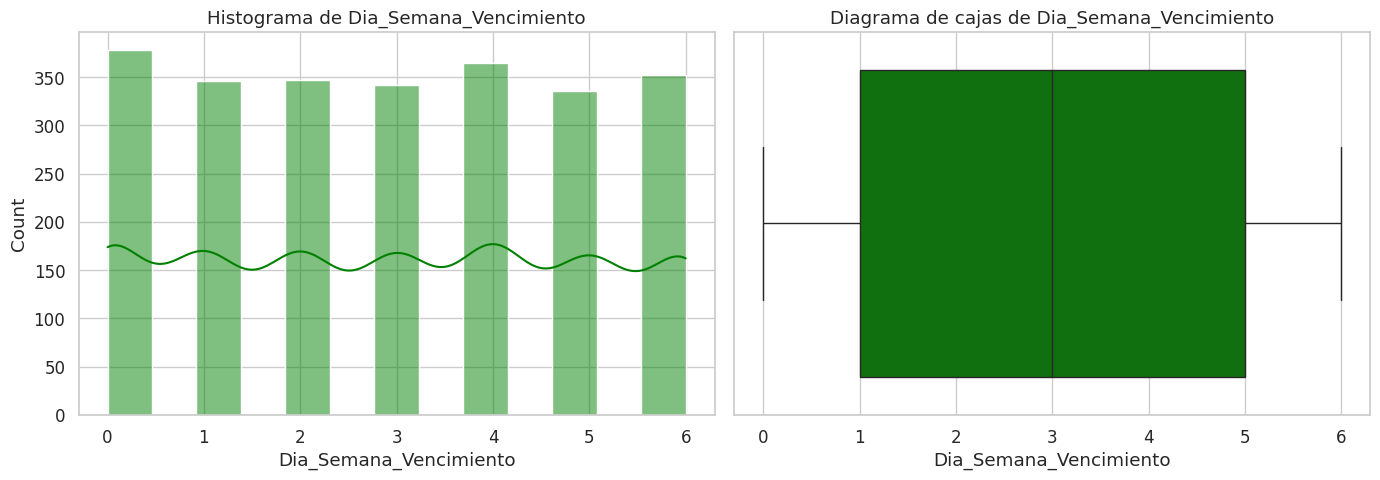

Columna: Tasa_Atraso_Historico
Asimetría (Skew): 0.52
Curtosis: -1.24


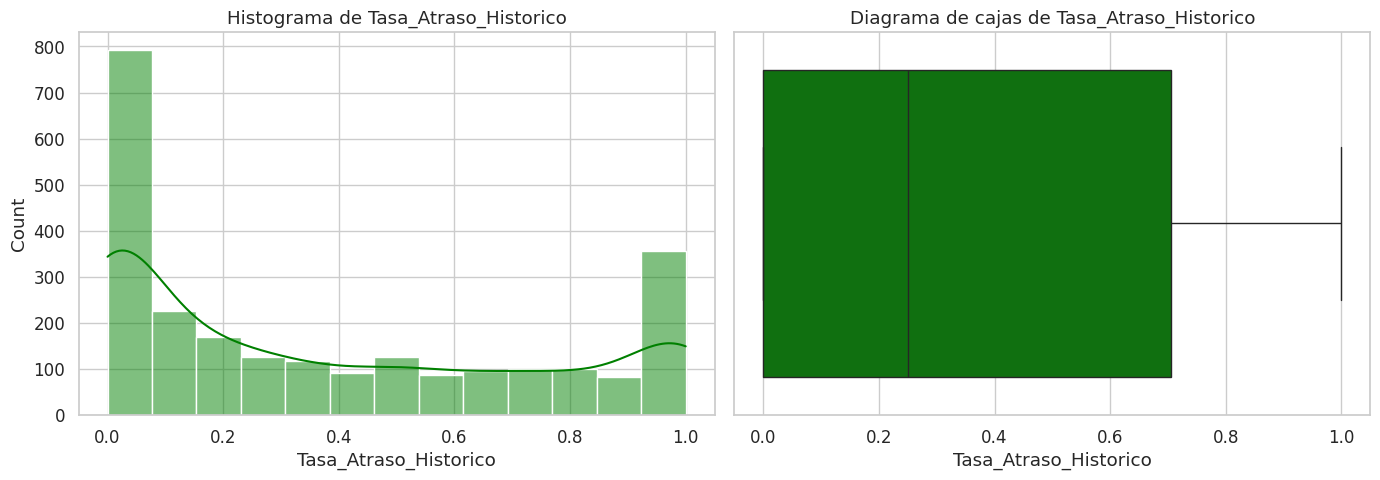

Columna: Promedio_Dias_Atraso_Historico
Asimetría (Skew): 1.48
Curtosis: 1.9


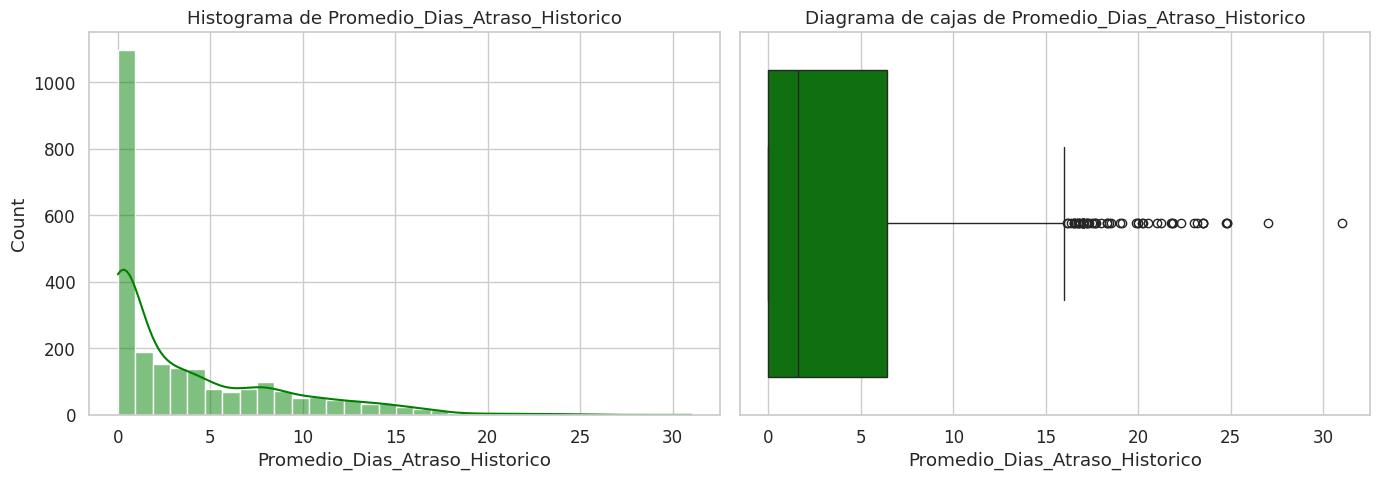

Columna: Facturas_Disputadas_Pasadas
Asimetría (Skew): 2.28
Curtosis: 5.69


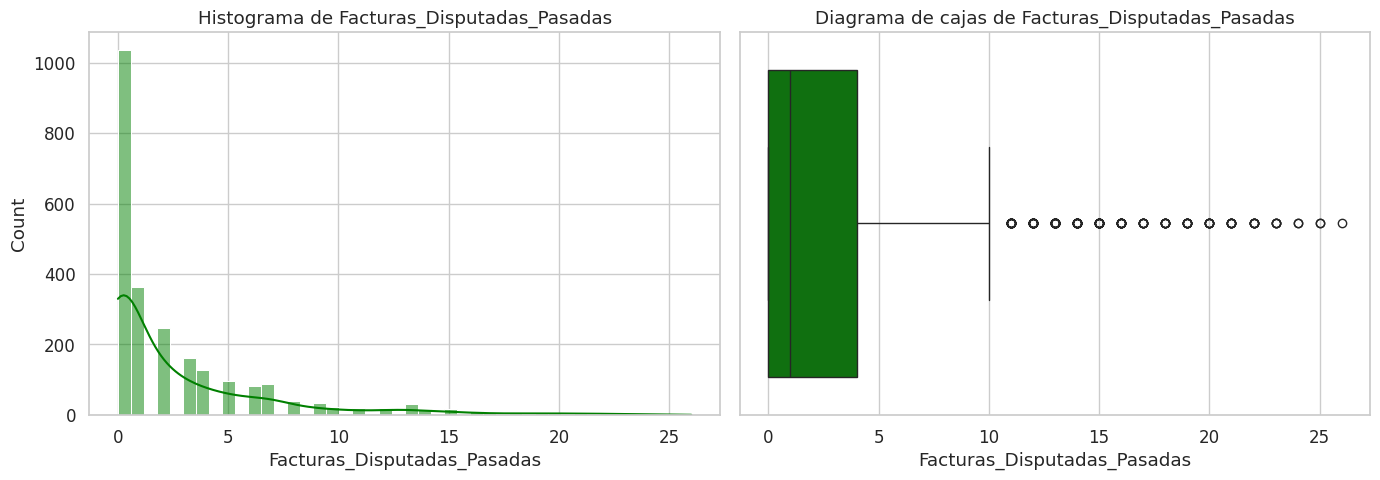

Columna: Facturas_Totales_Pasadas
Asimetría (Skew): 0.31
Curtosis: -0.74


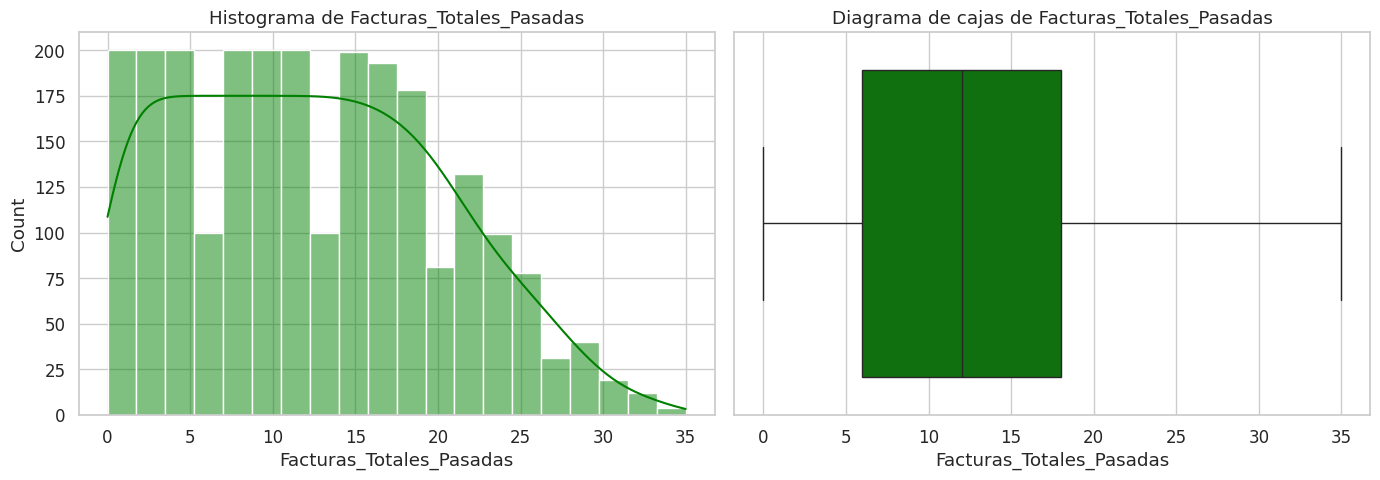

In [10]:
# Ajustar estilo de Seaborn
sns.set(style="whitegrid", font_scale=1.1)

# Visualización de la Variable Respuesta (Target)
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Target_EsAtrasado', data=df_eda, palette='dark:blue')
total = len(df_eda)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{count}\n({percentage:.1f}%)', (p.get_x() + p.get_width() / 2., count),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')
plt.title('Distribución de la Probabilidad de Atraso (Target)')
plt.ylim(0, ax.get_ylim()[1] * 1.1)
plt.savefig('/content/imagenes_eda/01_distribucion_target.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualización de Variables Numéricas (Histogramas y Boxplots)
num_cols = df_eda.select_dtypes(include=['float64', 'int64', 'int32']).drop(columns=['Target_EsAtrasado']).columns

for column in num_cols:
    print(f'Columna: {column}')
    print(f'Asimetría (Skew): {round(df_eda[column].skew(), 2)}')
    print(f'Curtosis: {round(df_eda[column].kurtosis(), 2)}')

    plt.figure(figsize=(14, 5))

    # Histograma con KDE
    plt.subplot(1, 2, 1)
    sns.histplot(df_eda[column], kde=True, color='green')
    plt.title(f'Histograma de {column}')

    # Diagrama de cajas
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_eda[column], color='green')
    plt.title(f'Diagrama de cajas de {column}')

    plt.tight_layout()
    plt.savefig(f'/content/imagenes_eda/02_distribucion_{column}.png', dpi=300, bbox_inches='tight')
    plt.show()

### Bloque 6: Visualización Bivariada (Pairplot)

Mapeamos las relaciones de las variables clave frente a nuestro objetivo.

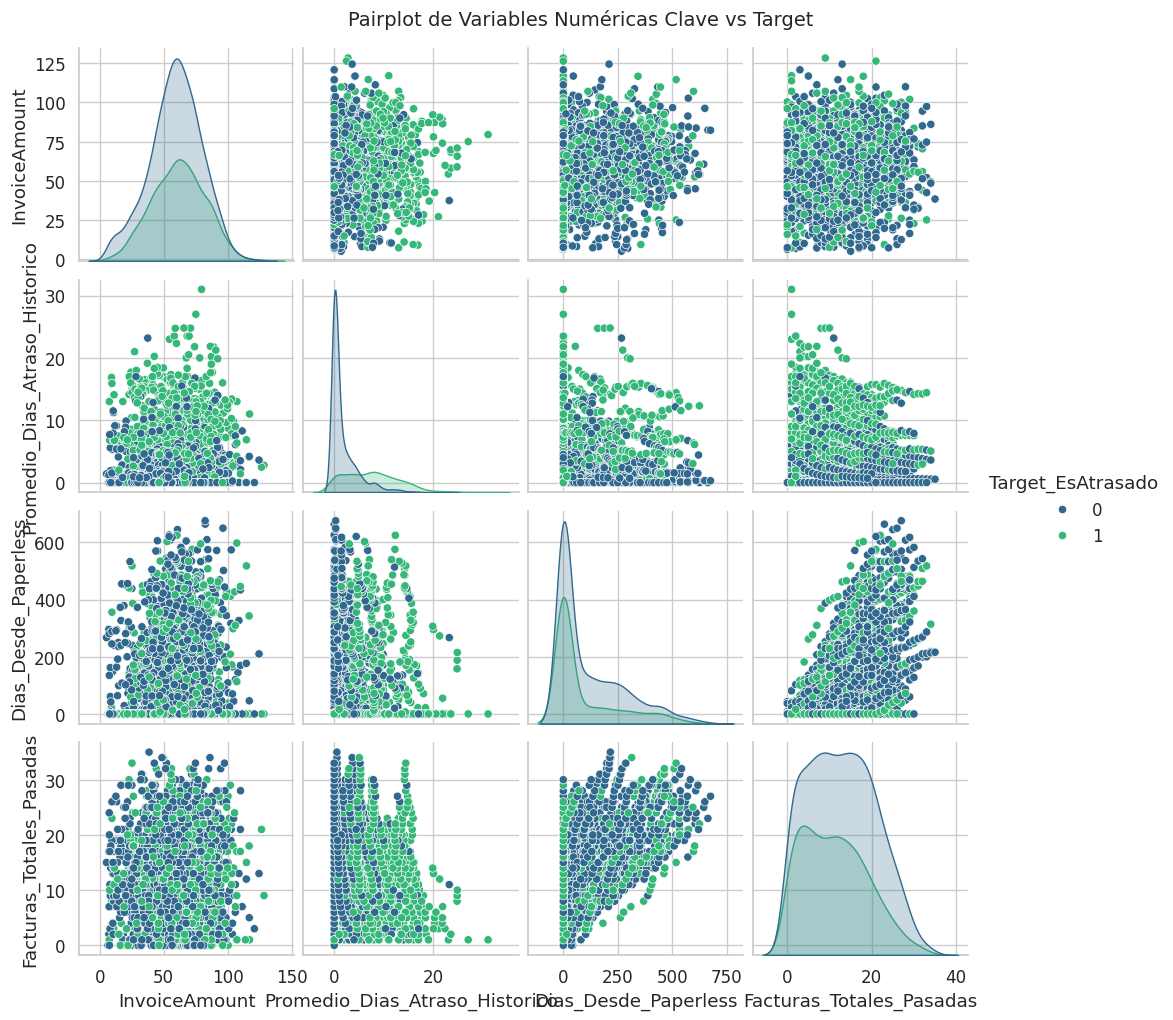

In [11]:
# Seleccionamos las columnas más representativas para no sobrecargar el Pairplot
cols_pairplot = ['InvoiceAmount', 'Promedio_Dias_Atraso_Historico', 'Dias_Desde_Paperless', 'Facturas_Totales_Pasadas', 'Target_EsAtrasado']

sns.pairplot(data=df_eda[cols_pairplot], hue='Target_EsAtrasado', diag_kind='kde', palette='viridis')
plt.suptitle('Pairplot de Variables Numéricas Clave vs Target', y=1.02, fontsize=14)
plt.savefig('/content/imagenes_eda/03_pairplot_variables_clave.png', dpi=300, bbox_inches='tight')
plt.show()

### Bloque 7: Matriz de Correlación (Spearman)

Verificamos colinealidad inicial utilizando el método de Spearman por ser variables con distribuciones asimétricas.

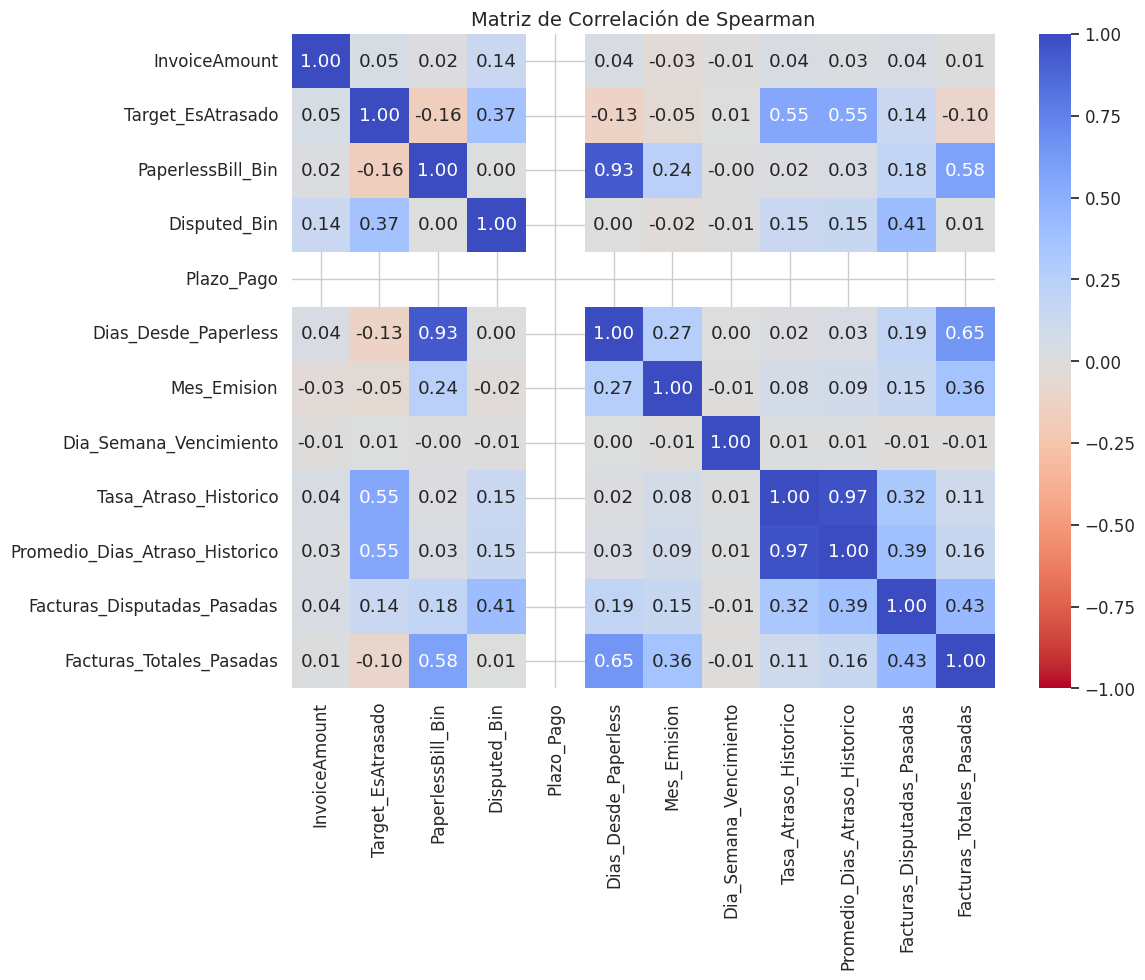

In [12]:
# Removemos variables categóricas puras para la correlación
df_cor = df_eda.drop(columns=['countryCode'])

# Calculamos correlación
correlation_matrix = df_cor.corr(method='spearman')

# Gráfica
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm_r', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Spearman', fontsize=14)
plt.tight_layout()
plt.savefig('/content/imagenes_eda/04_matriz_correlacion_spearman.png', dpi=300, bbox_inches='tight')
plt.show()

### Bloque 8: Análisis de VIF y Selección Final de Variables

Calculamos el Factor de Inflación de la Varianza (VIF) aplicando *One-Hot Encoding* preventivo a la variable país, y tomamos decisiones finales.

In [13]:
# 1. Separar características independientes (X)
X_completo = df_eda.drop(columns=['Target_EsAtrasado'])
col_categoricas = ['countryCode']
col_numericas = X_completo.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()

# 2. Codificar variables categóricas
encoder_ini = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_cat_encoded = encoder_ini.fit_transform(X_completo[col_categoricas])
nombres_cat = encoder_ini.get_feature_names_out(col_categoricas)

X_cat_df = pd.DataFrame(X_cat_encoded, columns=nombres_cat, index=X_completo.index)
X_unificado = pd.concat([X_completo[col_numericas], X_cat_df], axis=1)

# 3. Calcular VIF
X_vif = X_unificado.copy()
X_vif['intercept'] = 1
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Ordenar de mayor a menor peligro
vif_data = vif_data[vif_data["Variable"] != 'intercept'].sort_values(by="VIF", ascending=False)
print(" PRIMER VIF (EVALUACIÓN DE MULTICOLINEALIDAD) ")
print(vif_data.to_string(index=False))

# - SELECCIÓN FINAL -
# Tras evaluar el VIF y la correlación, eliminamos 'Plazo_Pago' (constante de 30 días, VIF 0)
# y 'Tasa_Atraso_Historico' (VIF > 5) para evitar redundancia y multicolinealidad severa.
# También 'PaperlessBill_Bin' por estar capturada en 'Dias_Desde_Paperless'.

columnas_definitivas = [
    'Target_EsAtrasado', 'countryCode', 'InvoiceAmount', 'Disputed_Bin',
    'Dias_Desde_Paperless', 'Mes_Emision', 'Dia_Semana_Vencimiento',
    'Promedio_Dias_Atraso_Historico', 'Facturas_Disputadas_Pasadas',
    'Facturas_Totales_Pasadas'
]

df_final = df_eda[columnas_definitivas]

print(f"Dimensiones finales: {df_final.shape}")


 PRIMER VIF (EVALUACIÓN DE MULTICOLINEALIDAD) 
                      Variable  VIF
         Tasa_Atraso_Historico 5.28
Promedio_Dias_Atraso_Historico 5.26
          Dias_Desde_Paperless 2.44
      Facturas_Totales_Pasadas 2.28
             PaperlessBill_Bin 2.22
   Facturas_Disputadas_Pasadas 1.85
               countryCode_406 1.71
               countryCode_897 1.66
               countryCode_818 1.59
               countryCode_770 1.54
                  Disputed_Bin 1.35
                 InvoiceAmount 1.31
                   Mes_Emision 1.17
        Dia_Semana_Vencimiento 1.00
                    Plazo_Pago 1.00
Dimensiones finales: (2466, 10)


In [17]:
#Para añadir imagenes al latex
#!zip -r /content/mi_carpeta.zip /content/imagenes_eda


In [18]:
#from google.colab import files
#files.download('/content/imagenes_eda.zip')
